# Colorbar utilities demo

Shows how to use `create_month_colorbar` and `create_diverging_colorbar` from
`global_snowmelt_runoff_onset.plot_utils` to build standalone colorbar figures
for use in publication figures.

In [1]:
import matplotlib.pyplot as plt

from global_snowmelt_runoff_onset.plot_utils import create_month_colorbar, create_diverging_colorbar

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['svg.fonttype'] = 'none'  # keep text editable in SVG

## `create_month_colorbar`

Horizontal colorbar for runoff onset date (day of water year), with month
names overlaid. The `hemisphere` argument controls which hemisphere's month
names are shown.

### `hemisphere="both"` (default)

Shows Northern Hemisphere month names (bold, top) and Southern Hemisphere
month names (italic, parenthesized, bottom).

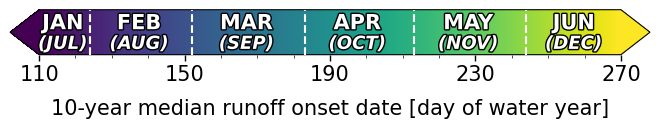

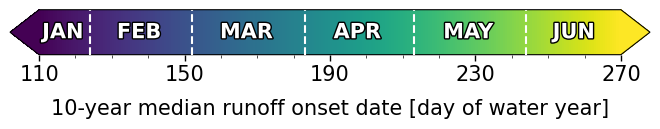

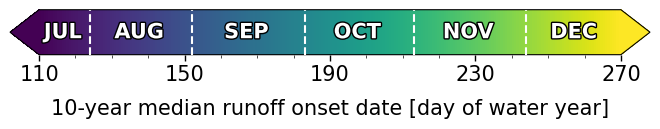

In [2]:
fig_both = create_month_colorbar(
    dowy_start=110,
    dowy_end=270,
    major_tick_spacing=40,
    minor_tick_spacing=10,
    hemisphere="both",
)
fig_north = create_month_colorbar(
    dowy_start=110,
    dowy_end=270,
    major_tick_spacing=40,
    minor_tick_spacing=10,
    hemisphere="northern",
)
fig_south = create_month_colorbar(
    dowy_start=110,
    dowy_end=270,
    major_tick_spacing=40,
    minor_tick_spacing=10,
    hemisphere="southern",
)

### Customizing colormap, figure size, and font sizes

All defaults match the original hand-tuned colorbars in
`analysis/create_colorbars.ipynb`, but can be overridden.

In [3]:
create_month_colorbar?

Signature:
create_month_colorbar(
    dowy_start,
    dowy_end,
    hemisphere='both',
    major_tick_spacing=40,
    minor_tick_spacing=10,
    cmap='viridis',
    figsize=(8, 3),
    ax=None,
    label='10-year median runoff onset date [day of water year]',
    label_fontsize=15,
    tick_labelsize=15,
    month_fontsize=None,
    abbreviate_month_names=True,
    display_month_if_no_room=True,
)
Docstring:
Create a horizontal colorbar for runoff onset date with month labels.

Parameters
----------
dowy_start : int
    Left edge of the colorbar (Day of Water Year).
dowy_end   : int
    Right edge of the colorbar (Day of Water Year).
hemisphere : {'both', 'northern', 'southern'}, default 'both'
    Which hemisphere's month names to display.  'both' shows Northern
    Hemisphere labels (bold, top) and Southern Hemisphere labels
    (italic, parenthesized, bottom).  'northern' / 'southern' show only
    that hemisphere's labels, centered vertically.
major_tick_spacing : int
    Spacing b

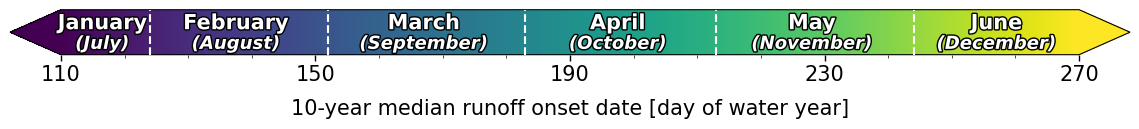

In [4]:
fig_both = create_month_colorbar(
    dowy_start=110,
    dowy_end=270,
    major_tick_spacing=40,
    minor_tick_spacing=10,
    hemisphere="both",
    abbreviate_month_names=False,
    figsize=(14, 3),
)

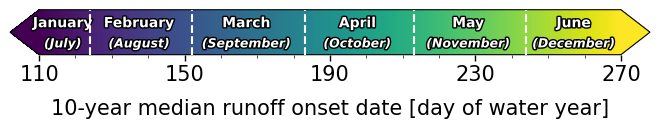

In [5]:
fig_both = create_month_colorbar(
    dowy_start=110,
    dowy_end=270,
    major_tick_spacing=40,
    minor_tick_spacing=10,
    hemisphere="both",
    abbreviate_month_names=False,
    month_fontsize=10,

)

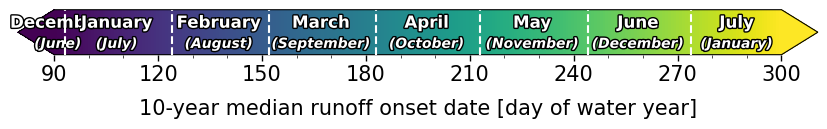

In [6]:
fig = create_month_colorbar(
    dowy_start=90,
    dowy_end=300,
    major_tick_spacing=30,
    minor_tick_spacing=10,
    hemisphere="both",
    cmap="viridis",
    figsize=(10, 3),
    label="10-year median runoff onset date [day of water year]",
    label_fontsize=15,
    tick_labelsize=15,
    abbreviate_month_names=False,
)

## `create_diverging_colorbar`

Horizontal diverging colorbar with optional left/right text annotations,
e.g. for runoff onset anomalies relative to a median.

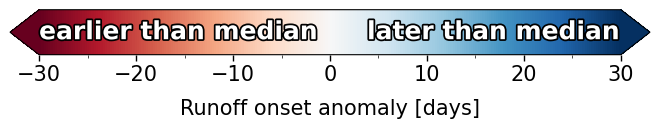

In [7]:
fig = create_diverging_colorbar(
    vmin=-30,
    vmax=30,
    cmap="RdBu",
    label="Runoff onset anomaly [days]",
    ticks=[-30, -20, -10, 0, 10, 20, 30],
    minor_tick_spacing=5,
    left_text="earlier than median",
    right_text="later than median",
)

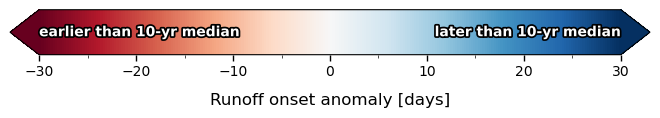

In [8]:
fig = create_diverging_colorbar(
    vmin=-30,
    vmax=30,
    cmap="RdBu",
    label="Runoff onset anomaly [days]",
    ticks=[-30, -20, -10, 0, 10, 20, 30],
    minor_tick_spacing=5,
    left_text='earlier than 10-yr median',
    right_text='later than 10-yr median',
    label_fontsize=12, 
    tick_labelsize=10, 
    text_fontsize=10,
)

### Other diverging colorbars

The function works for any diverging colormap and value range, e.g. the
temperature-sensitivity colorbar (`YlOrRd_r`, sequential but used here as an
example of custom ticks/labels).

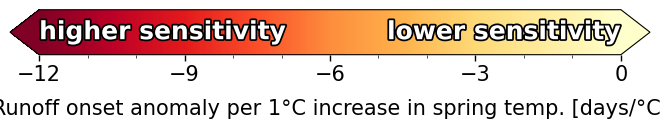

In [9]:
fig = create_diverging_colorbar(
    vmin=-12,
    vmax=0,
    cmap="YlOrRd_r",
    label="Runoff onset anomaly per 1\u00b0C increase in spring temp. [days/\u00b0C]",
    ticks=[-12, -9, -6, -3, 0],
    minor_tick_spacing=1,
    left_text="higher sensitivity",
    right_text="lower sensitivity",
)

## Saving figures

Both functions return a `matplotlib.figure.Figure` and never write to disk.
Save with `fig.savefig(...)` as needed:

```python
fig.savefig("colorbars/my_colorbar.svg", bbox_inches="tight", dpi=300,
             facecolor="white", edgecolor="none", pad_inches=0.1)
```

## Embedding colorbars in a larger figure

Both functions accept an `ax` parameter. When given, the colorbar is drawn
directly onto that axes instead of creating its own standalone figure --
handy for combining a map and one or more colorbars in a single `GridSpec`
layout. `figsize` is ignored in this case, and the function still returns a
`Figure` (the `ax`'s parent figure), so saving works the same way.

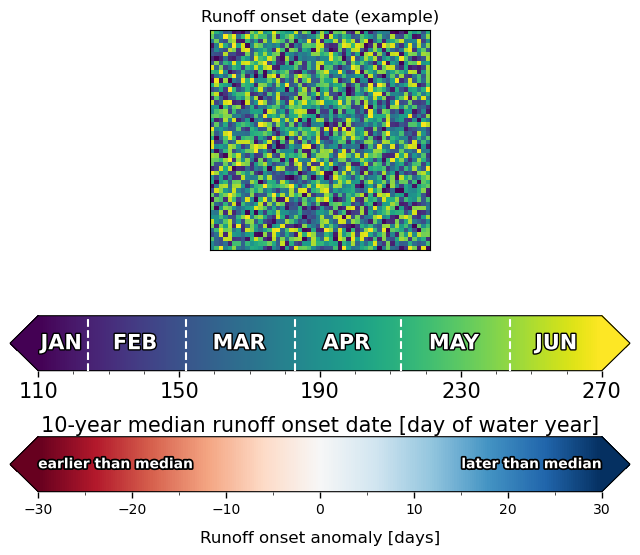

In [10]:
import numpy as np

fig = plt.figure(figsize=(8, 6))
gs = fig.add_gridspec(3, 1, height_ratios=[4, 1, 1], hspace=0.6)

# "map" panel
ax_map = fig.add_subplot(gs[0])
data = np.random.default_rng(0).integers(110, 270, size=(50, 50))
ax_map.imshow(data, cmap="viridis", vmin=110, vmax=270)
ax_map.set_title("Runoff onset date (example)")
ax_map.set_xticks([])
ax_map.set_yticks([])

# month colorbar embedded as a subplot
cax_month = fig.add_subplot(gs[1])
create_month_colorbar(
    dowy_start=110,
    dowy_end=270,
    major_tick_spacing=40,
    minor_tick_spacing=10,
    hemisphere="northern",
    ax=cax_month,
)

# diverging colorbar embedded as a subplot
cax_div = fig.add_subplot(gs[2])
create_diverging_colorbar(
    vmin=-30,
    vmax=30,
    cmap="RdBu",
    label="Runoff onset anomaly [days]",
    ticks=[-30, -20, -10, 0, 10, 20, 30],
    minor_tick_spacing=5,
    left_text="earlier than median",
    right_text="later than median",
    label_fontsize=12,
    tick_labelsize=10,
    text_fontsize=10,
    ax=cax_div,
);

## Old code

In [ ]:
# import matplotlib.pyplot as plt
# import matplotlib as mpl
# from matplotlib.ticker import MultipleLocator
# from matplotlib.patheffects import withStroke

# # Set professional font for academic publication
# plt.rcParams['font.family'] = 'sans-serif'
# plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
# plt.rcParams['svg.fonttype'] = 'none'  # Ensure text is editable in SVG


# base_path = r"colorbars/"

# import matplotlib as mpl
# import matplotlib.pyplot as plt
# from matplotlib.ticker import MultipleLocator
# from matplotlib.patheffects import withStroke
# import os


# # ─── Water-year calendar ────────────────────────────────────────────────────
# # DOWY 1 = Oct 1  (non-leap year)
# _MONTH_STARTS = [1,  32,  62,  93, 124, 152, 183, 213, 244, 274, 305, 336]
# _MONTH_ENDS   = [31, 61,  92, 123, 151, 182, 212, 243, 273, 304, 335, 365]

# # Northern Hemisphere calendar months (water-year order Oct → Sep)
# _NH_LONG  = ['October', 'November', 'December', 'January', 'February',
#              'March',   'April',    'May',       'June',    'July',
#              'August',  'September']
# _NH_SHORT = ['OCT', 'NOV', 'DEC', 'JAN', 'FEB',
#              'MAR', 'APR', 'MAY', 'JUN', 'JUL',
#              'AUG', 'SEP']

# # Southern Hemisphere equivalents (6-month offset in calendar)
# _SH_LONG  = ['April',   'May',      'June',     'July',    'August',
#              'September','October', 'November', 'December', 'January',
#              'February', 'March']
# _SH_SHORT = ['APR', 'MAY', 'JUN', 'JUL', 'AUG',
#              'SEP', 'OCT', 'NOV', 'DEC', 'JAN',
#              'FEB', 'MAR']


# def create_month_colorbars(dowy_start, dowy_end, base_path,
#                            major_tick_spacing=30, minor_tick_spacing=10,
#                            file_suffix='', save_svg=True, save_png=True,
#                            abbreviate_month_names=False,
#                            display_month_if_no_room=False):
#     """
#     Create two horizontal viridis colorbars for runoff onset date.

#     Parameters
#     ----------
#     dowy_start : int
#         Left edge of the colorbar (Day of Water Year).
#     dowy_end   : int
#         Right edge of the colorbar (Day of Water Year).
#     base_path  : str
#         Output directory.
#     major_tick_spacing : int
#         Spacing between labelled major ticks in DOWY units.  Ticks are placed
#         at dowy_start, dowy_start + major_tick_spacing, … up to dowy_end,
#         so the endpoints are always labelled regardless of the step size.
#         Example: dowy_start=110, dowy_end=270, major_tick_spacing=40 gives
#         ticks at 110, 150, 190, 230, 270.
#     minor_tick_spacing : int
#         Spacing between unlabelled minor ticks in DOWY units.
#     file_suffix : str, optional
#         Extra string appended before the extension, e.g. '_fig2'.
#     save_svg / save_png : bool
#         Toggle SVG / PNG output independently.
#     abbreviate_month_names : bool, default False
#         If True, use 3-letter abbreviations (Jan, Feb, …) instead of full
#         names.  Full names are always used unless this is explicitly True.
#     display_month_if_no_room : bool, default False
#         If False (default), a month label is silently omitted when its
#         visible slot is too narrow to fit the text at the current font size.
#         If True, the label is drawn regardless — it will overlap the
#         boundary lines on cramped colorbars.

#     Saves
#     -----
#     <base_path>/viridis_month_colorbar_<start>_<end><suffix>_dual.{svg,png}
#         Colorbar with NH month labels (top) and SH month labels in italics
#         (bottom).
#     <base_path>/viridis_month_colorbar_<start>_<end><suffix>_nh.{svg,png}
#         Colorbar with NH month labels only (centred).
#     """

#     total_range = dowy_end - dowy_start
#     if total_range <= 0:
#         raise ValueError("dowy_end must be greater than dowy_start.")

#     # ── Find months that overlap with [dowy_start, dowy_end] ─────────────────
#     boundaries = []   # internal month-boundary lines that fall inside the range
#     visible   = []    # list of dicts with positioning info per visible month

#     for ms, me, nh_l, nh_s, sh_l, sh_s in zip(
#             _MONTH_STARTS, _MONTH_ENDS,
#             _NH_LONG, _NH_SHORT, _SH_LONG, _SH_SHORT):

#         if me <= dowy_start or ms >= dowy_end:
#             continue

#         vis_start = max(ms, dowy_start)
#         vis_end   = min(me, dowy_end)
#         center    = (vis_start + vis_end) / 2
#         width     = vis_end - vis_start

#         visible.append(dict(center=center, width=width,
#                             nh_long=nh_l, nh_short=nh_s,
#                             sh_long=sh_l, sh_short=sh_s))

#         # Internal boundary (month start that falls strictly inside the range)
#         if dowy_start < ms < dowy_end:
#             boundaries.append(ms)

#     if not visible:
#         raise ValueError(f"No months fall in DOWY range {dowy_start}–{dowy_end}.")

#     # ── Font-size heuristic ──────────────────────────────────────────────────
#     # Base font size on the narrowest *fully-visible* month slot.  Months
#     # that are edge-clipped to fewer than 15 days (e.g. the 2-day stub of
#     # December when dowy_start=90) are excluded so they don't drag the font
#     # size down to an unreadably small value — those stubs will simply fail
#     # the per-label fit check and be silently skipped.
#     sizing_widths = [m['width'] for m in visible if m['width'] >= 15]
#     if not sizing_widths:                        # all months are tiny stubs
#         sizing_widths = [m['width'] for m in visible]
#     min_width  = min(sizing_widths)
#     proportion = min_width / total_range        # fraction of bar width

#     # Font size: reference point → prop=0.15 gives size 14; clamped [10, 20]
#     raw_fs = round(95 * proportion)             # 95 = 14 / 0.15 (raised from 87)
#     fs_top = max(10, min(20, raw_fs))
#     fs_bot = max(9, fs_top - 2)                # SH labels slightly smaller

#     # ── Per-month fit check ───────────────────────────────────────────────────
#     # Estimate whether a string fits inside a slot of a given width (in DOWY
#     # units).  The colorbar axes span 0.80 × 8 in = 6.4 in of figure width.
#     # At fontsize pt, a bold character is ~0.65 × (pt/72) inches wide.
#     # We add a small horizontal padding factor (1.15×) to avoid edge crowding.
#     BAR_WIDTH_IN  = 0.80 * 8.0   # inches
#     CHAR_WIDTH_EM = 0.58          # bold-font character width relative to pt size
#     PAD_FACTOR    = 1.05          # extra breathing room

#     def _fits(label: str, slot_width_dowy: float, fontsize: float) -> bool:
#         slot_in   = (slot_width_dowy / total_range) * BAR_WIDTH_IN
#         text_in   = len(label) * CHAR_WIDTH_EM * (fontsize / 72.0) * PAD_FACTOR
#         return text_in <= slot_in

#     # ── Tick layout ──────────────────────────────────────────────────────────
#     major_ticks = list(range(dowy_start, dowy_end + 1, major_tick_spacing))
#     if major_ticks[-1] != dowy_end:
#         major_ticks.append(dowy_end)

#     norm = mpl.colors.Normalize(vmin=dowy_start, vmax=dowy_end)
#     label_text = '10-year median runoff onset date [day of water year]'

#     # ── Builder ──────────────────────────────────────────────────────────────
#     def _build(with_sh: bool):
#         fig_h  = 3#3.2 if with_sh else 2.2
#         fig = plt.figure(figsize=(8, fig_h))
#         #ax  = fig.add_axes([0.10, 0.50, 0.80, 0.20])
#         ax = fig.add_axes([0.10, 0.45, 0.80, 0.15])

#         cb = mpl.colorbar.ColorbarBase(
#             ax, orientation='horizontal', cmap='viridis',
#             norm=norm, ticks=major_ticks, extend='both')

#         cb.set_label(label_text, fontsize=15, weight='normal', labelpad=10)
#         cb.ax.tick_params(labelsize=15, length=4, width=1)
#         cb.ax.xaxis.set_minor_locator(MultipleLocator(minor_tick_spacing))
#         cb.ax.tick_params(which='minor', length=2, width=0.5)

#         # Month boundary lines
#         for b in boundaries:
#             ax.axvline(x=b, ymin=0, ymax=1,
#                        color='white', linewidth=1.5, linestyle='--', zorder=10)

#         # Month labels
#         for m in visible:
#             c     = m['center']
#             width = m['width']
#             nh    = m['nh_short'] if abbreviate_month_names else m['nh_long']
#             sh    = m['sh_short'] if abbreviate_month_names else m['sh_long']

#             y_nh = 0.7 if with_sh else 0.5
#             y_sh = 0.24

#             # NH label
#             if display_month_if_no_room or _fits(nh, width, fs_top):
#                 t = ax.text(c, y_nh, nh, fontsize=fs_top,
#                             ha='center', va='center', color='white',
#                             weight='bold', transform=ax.transData, clip_on=False)
#                 t.set_path_effects([withStroke(linewidth=2, foreground='black')])

#             # SH label (parenthesised)
#             if with_sh:
#                 sh_label = f'({sh})'
#                 if display_month_if_no_room or _fits(sh_label, width, fs_bot):
#                     t2 = ax.text(c, y_sh, sh_label, fontsize=fs_bot,
#                                  ha='center', va='center', color='white',
#                                  weight='bold', style='italic',
#                                  transform=ax.transData, clip_on=False)
#                     t2.set_path_effects([withStroke(linewidth=2, foreground='black')])

#         return fig

#     # ── Save helper ──────────────────────────────────────────────────────────
#     base_name = (f"viridis_month_colorbar_{dowy_start}_{dowy_end}"
#                  f"{file_suffix}")

#     def _save(fig, tag):
#         stem = os.path.join(base_path, f"{base_name}_{tag}")
#         kw = dict(bbox_inches='tight', dpi=300,
#                   facecolor='white', edgecolor='none', pad_inches=0.1)
#         if save_svg:
#             fig.savefig(stem + '.svg', **kw)
#         if save_png:
#             fig.savefig(stem + '.png', **kw)
#         print(f"Saved {stem}.{'svg+png' if save_svg and save_png else 'svg' if save_svg else 'png'}")
#         plt.close(fig)

#     _save(_build(with_sh=True),  'dual')
#     _save(_build(with_sh=False), 'nh')


# # # ── Quick demo (remove / comment out in production) ─────────────────────────
# # if __name__ == '__main__':
# #     import tempfile
# #     out = tempfile.mkdtemp()
# #     print(f"Saving demo colorbars to: {out}\n")

# #     create_month_colorbars(110, 270, out, major_tick_spacing=40, minor_tick_spacing=10, file_suffix='_110_270')
# #     create_month_colorbars(90,  270, out, major_tick_spacing=30, minor_tick_spacing=10, file_suffix='_90_270')
# #     create_month_colorbars(100, 300, out, major_tick_spacing=30, minor_tick_spacing=10, file_suffix='_100_300')
# #     create_month_colorbars(32,  335, out, major_tick_spacing=60, minor_tick_spacing=30, file_suffix='_32_335')


# create_month_colorbars(dowy_start=110, 
#                        dowy_end=270, 
#                        major_tick_spacing=40, 
#                        minor_tick_spacing=10, 
#                        base_path='colorbars/', 
#                        file_suffix='', 
#                        display_month_if_no_room=True, 
#                        abbreviate_month_names=True, 
#                        save_svg=True, 
#                        save_png=False)


# # ============= 1. SENSITIVITY COLORBARS =============
# # HORIZONTAL
# fig = plt.figure(figsize=(8, 3))
# ax = fig.add_axes([0.10, 0.45, 0.80, 0.15])
# norm = mpl.colors.Normalize(vmin=-12, vmax=0)
# cb = mpl.colorbar.ColorbarBase(ax, orientation='horizontal', cmap='YlOrRd_r', norm=norm,
#                                 ticks=[-12, -9, -6, -3, 0], extend='both')
# cb.set_label('Runoff onset anomaly per 1°C increase in spring temp. [days/°C]', 
#              fontsize=15, weight='normal', labelpad=10)
# cb.ax.tick_params(labelsize=15, length=4, width=1)
# cb.ax.xaxis.set_minor_locator(MultipleLocator(1))
# cb.ax.tick_params(which='minor', length=2, width=0.5)

# # Text at 10% and 90% of range: -15 + 0.1*15 = -13.5, -15 + 0.9*15 = -1.5
# text1 = ax.text(-10.8, 0.5, 'higher sensitivity', fontsize=18, ha='left', va='center', 
#                 color='white', weight='bold', transform=ax.transData)
# text1.set_path_effects([withStroke(linewidth=2.5, foreground='black')])
# text2 = ax.text(-1.2, 0.5, 'lower sensitivity', fontsize=18, ha='right', va='center', 
#                 color='white', weight='bold', transform=ax.transData)
# text2.set_path_effects([withStroke(linewidth=2.5, foreground='black')])
# # arrow1 = ax.text(-12, 0.5, '←', fontsize=24, ha='center', va='center', 
# #                  color='white', weight='bold', transform=ax.transData)
# # arrow1.set_path_effects([withStroke(linewidth=3, foreground='black')])
# # arrow2 = ax.text(-3, 0.5, '→', fontsize=24, ha='center', va='center', 
# #                  color='white', weight='bold', transform=ax.transData)
# # arrow2.set_path_effects([withStroke(linewidth=3, foreground='black')])

# fig.savefig(f"{base_path}\\snowmelt_temp_anomaly_choropleth_colorbar_horizontal.svg", 
#             bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none', pad_inches=0.1)
# fig.savefig(f"{base_path}\\snowmelt_temp_anomaly_choropleth_colorbar_horizontal.png", 
#             bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none', pad_inches=0.2)
# print('Saved sensitivity horizontal (SVG and PNG)')
# plt.close(fig)


# # ============= 2. MONTHS COLORBARS (Original: 100-300) =============
# # HORIZONTAL
# fig2 = plt.figure(figsize=(8, 3))
# ax2 = fig2.add_axes([0.10, 0.50, 0.80, 0.15])
# norm2 = mpl.colors.Normalize(vmin=100, vmax=300)
# cb2 = mpl.colorbar.ColorbarBase(ax2, orientation='horizontal', cmap='viridis', norm=norm2,
#                                 ticks=[100, 150, 200, 250, 300], extend='both')
# cb2.set_label('10-year median runoff onset date [day of water year]', 
#              fontsize=15, weight='normal', labelpad=10)
# cb2.ax.tick_params(labelsize=15, length=4, width=1)
# cb2.ax.xaxis.set_minor_locator(MultipleLocator(10))
# cb2.ax.tick_params(which='minor', length=2, width=0.5)

# # Add month boundary lines using axis coordinates
# month_boundaries = [124, 152, 183, 213, 244, 274]
# for boundary in month_boundaries:
#     ax2.axvline(x=boundary, ymin=0, ymax=1, color='white', 
#                 linewidth=1.2, linestyle='--', zorder=10)

# # Add month labels using axis coordinates
# white_month_labels = ['January', 'February', 'March', 'April', 'May', 'June', 'July']
# white_month_centers = [(98 + 124) / 2, (124 + 152) / 2, (152 + 183) / 2, 
#                        (183 + 213) / 2, (213 + 244) / 2, (244 + 274) / 2, (274 + 300) / 2]
# for center, label in zip(white_month_centers, white_month_labels):
#     text = ax2.text(center, 0.65, label, fontsize=13, ha='center', va='center', 
#                     color='white', weight='bold', rotation=0, 
#                     transform=ax2.transData)
#     text.set_path_effects([withStroke(linewidth=2, foreground='black')])

# # Bottom labels in italics without parentheses
# italic_month_labels = ['(July)', '(August)', '(September)', '(October)', '(November)', '(December)', '(January)']
# for center, label in zip(white_month_centers, italic_month_labels):
#     text = ax2.text(center, 0.30, label, fontsize=10, ha='center', va='center', 
#                     color='white', weight='bold', style='italic', rotation=0,
#                     transform=ax2.transData)
#     text.set_path_effects([withStroke(linewidth=2, foreground='black')])

# fig2.savefig(f"{base_path}\\viridis_month_colorbar_horizontal.svg", 
#             bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none', pad_inches=0.1)
# fig2.savefig(f"{base_path}\\viridis_month_colorbar_horizontal.png", 
#             bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none', pad_inches=0.1)
# print('Saved months horizontal (100-300) (SVG and PNG)')
# plt.close(fig2)


# # ============= 2b. MONTHS COLORBARS (Finer: 110-270) =============
# # HORIZONTAL
# fig2b = plt.figure(figsize=(8, 3))
# ax2b = fig2b.add_axes([0.10, 0.50, 0.80, 0.15])
# norm2b = mpl.colors.Normalize(vmin=110, vmax=270)
# cb2b = mpl.colorbar.ColorbarBase(ax2b, orientation='horizontal', cmap='viridis', norm=norm2b,
#                                 ticks=[110, 150, 180, 210, 240, 270], extend='both')
# cb2b.set_label('10-year median runoff onset date [day of water year]', 
#              fontsize=15, weight='normal', labelpad=10)
# cb2b.ax.tick_params(labelsize=15, length=4, width=1)
# cb2b.ax.xaxis.set_minor_locator(MultipleLocator(10))
# cb2b.ax.tick_params(which='minor', length=2, width=0.5)

# # Add month boundary lines
# month_boundaries_fine = [124, 152, 183, 213, 244]
# for boundary in month_boundaries_fine:
#     ax2b.axvline(x=boundary, ymin=0, ymax=1, color='white', 
#                  linewidth=1.5, linestyle='--', zorder=10)

# # Add month labels
# white_month_labels_fine = ['January', 'February', 'March', 'April', 'May', 'June']
# white_month_centers_fine = [
#     (110 + 124) / 2 - 3,  # Shift January left
#     (124 + 152) / 2, 
#     (152 + 183) / 2,
#     (183 + 213) / 2, 
#     (213 + 244) / 2, 
#     (244 + 270) / 2
# ]
# for center, label in zip(white_month_centers_fine, white_month_labels_fine):
#     text = ax2b.text(center, 0.65, label, fontsize=13, ha='center', va='center', 
#                      color='white', weight='bold', rotation=0,
#                      transform=ax2b.transData)
#     text.set_path_effects([withStroke(linewidth=2, foreground='black')])

# # Bottom labels in italics without parentheses
# italic_month_labels_fine = ['(July)', '(August)', '(September)', '(October)', '(November)', '(December)']
# italic_month_centers_fine = [
#     (110 + 124) / 2 - 3,  # Shift July left
#     (124 + 152) / 2,
#     (152 + 183) / 2,
#     (183 + 213) / 2,
#     (213 + 244) / 2,
#     (244 + 270) / 2
# ]
# for center, label in zip(italic_month_centers_fine, italic_month_labels_fine):
#     text = ax2b.text(center, 0.30, label, fontsize=11, ha='center', va='center', 
#                      color='white', weight='bold', style='italic', rotation=0,
#                      transform=ax2b.transData)
#     text.set_path_effects([withStroke(linewidth=2, foreground='black')])

# fig2b.savefig(f"{base_path}\\viridis_month_colorbar_fine_horizontal.svg", 
#             bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none', pad_inches=0.1)
# fig2b.savefig(f"{base_path}\\viridis_month_colorbar_fine_horizontal.png", 
#             bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none', pad_inches=0.1)
# print('Saved months horizontal (110-270 fine) (SVG and PNG)')
# plt.close(fig2b)

# # ============= 2b. MONTHS COLORBARS (Finer: 110-270) 3 PAN =============
# # HORIZONTAL
# fig2b = plt.figure(figsize=(8, 3))
# ax2b = fig2b.add_axes([0.10, 0.50, 0.80, 0.15])
# norm2b = mpl.colors.Normalize(vmin=110, vmax=270)
# cb2b = mpl.colorbar.ColorbarBase(ax2b, orientation='horizontal', cmap='viridis', norm=norm2b,
#                                 ticks=[110, 150, 190, 230, 270], extend='both')
# cb2b.set_label('10-year median runoff onset date [day of water year]', 
#              fontsize=15, weight='normal', labelpad=7)
# cb2b.ax.tick_params(labelsize=15, length=4, width=1)
# cb2b.ax.xaxis.set_minor_locator(MultipleLocator(10))
# cb2b.ax.tick_params(which='minor', length=2, width=0.5)

# # Add month boundary lines
# month_boundaries_fine = [124, 152, 183, 213, 244]
# for boundary in month_boundaries_fine:
#     ax2b.axvline(x=boundary, ymin=0, ymax=1, color='white', 
#                  linewidth=1.5, linestyle='--', zorder=10)

# # Add month labels
# white_month_labels_fine = ['January', 'February', 'March', 'April', 'May', 'June']
# white_month_centers_fine = [
#     (110 + 124) / 2 - 3,  # Shift January left
#     (124 + 152) / 2, 
#     (152 + 183) / 2,
#     (183 + 213) / 2, 
#     (213 + 244) / 2, 
#     (244 + 270) / 2
# ]
# for center, label in zip(white_month_centers_fine, white_month_labels_fine):
#     text = ax2b.text(center, 0.65, label, fontsize=13, ha='center', va='center', 
#                      color='white', weight='bold', rotation=0,
#                      transform=ax2b.transData)
#     text.set_path_effects([withStroke(linewidth=2, foreground='black')])

# # Bottom labels in italics without parentheses
# italic_month_labels_fine = ['(July)', '(August)', '(September)', '(October)', '(November)', '(December)']
# italic_month_centers_fine = [
#     (110 + 124) / 2 - 3,  # Shift July left
#     (124 + 152) / 2,
#     (152 + 183) / 2,
#     (183 + 213) / 2,
#     (213 + 244) / 2,
#     (244 + 270) / 2
# ]
# for center, label in zip(italic_month_centers_fine, italic_month_labels_fine):
#     text = ax2b.text(center, 0.30, label, fontsize=11, ha='center', va='center', 
#                      color='white', weight='bold', style='italic', rotation=0,
#                      transform=ax2b.transData)
#     text.set_path_effects([withStroke(linewidth=2, foreground='black')])

# fig2b.savefig(f"{base_path}\\viridis_month_colorbar_fine_horizontal_3pan.svg", 
#             bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none', pad_inches=0.1)
# fig2b.savefig(f"{base_path}\\viridis_month_colorbar_fine_horizontal_3pan.png", 
#             bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none', pad_inches=0.1)
# print('Saved months horizontal (110-270 fine) (SVG and PNG)')
# plt.close(fig2b)




# # ============= 3. ELEVATION DELAY COLORBARS =============
# # HORIZONTAL
# fig3 = plt.figure(figsize=(8, 3))
# ax3 = fig3.add_axes([0.10, 0.45, 0.80, 0.15])
# norm3 = mpl.colors.Normalize(vmin=0, vmax=8)
# cb3 = mpl.colorbar.ColorbarBase(ax3, orientation='horizontal', cmap='YlGnBu', norm=norm3,
#                                 ticks=[0, 2, 4, 6, 8], extend='both')
# cb3.set_label('Delay in runoff onset per 100 meter increase in elevation [days/100m]', 
#              fontsize=15, weight='normal', labelpad=10)
# cb3.ax.tick_params(labelsize=15, length=4, width=1)
# cb3.ax.xaxis.set_minor_locator(MultipleLocator(1))
# cb3.ax.tick_params(which='minor', length=2, width=0.5)

# # Text at 10% and 90% of range: 0 + 0.1*8 = 0.8, 0 + 0.9*8 = 7.2
# text1 = ax3.text(0.8, 0.5, 'weaker delay', fontsize=18, ha='left', va='center', 
#                  color='white', weight='bold', transform=ax3.transData)
# text1.set_path_effects([withStroke(linewidth=2.5, foreground='black')])
# text2 = ax3.text(7.2, 0.5, 'stronger delay', fontsize=18, ha='right', va='center', 
#                  color='white', weight='bold', transform=ax3.transData)
# text2.set_path_effects([withStroke(linewidth=2.5, foreground='black')])
# # arrow1 = ax3.text(1.6, 0.5, '←', fontsize=24, ha='center', va='center', 
# #                   color='white', weight='bold', transform=ax3.transData)
# # arrow1.set_path_effects([withStroke(linewidth=3, foreground='black')])
# # arrow2 = ax3.text(6.4, 0.5, '→', fontsize=24, ha='center', va='center', 
# #                   color='white', weight='bold', transform=ax3.transData)
# # arrow2.set_path_effects([withStroke(linewidth=3, foreground='black')])

# fig3.savefig(f"{base_path}\\elevation_delay_colorbar_horizontal.svg", 
#             bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none', pad_inches=0.1)
# fig3.savefig(f"{base_path}\\elevation_delay_colorbar_horizontal.png", 
#             bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none', pad_inches=0.1)
# print('Saved elevation delay horizontal (SVG and PNG)')
# plt.close(fig3)


# # ============= 4. RUNOFF ONSET ANOMALY COLORBARS =============
# # HORIZONTAL
# fig4 = plt.figure(figsize=(8, 3))
# ax4 = fig4.add_axes([0.10, 0.45, 0.80, 0.15])
# norm4 = mpl.colors.Normalize(vmin=-30, vmax=30)
# cb4 = mpl.colorbar.ColorbarBase(ax4, orientation='horizontal', cmap='RdBu', norm=norm4,
#                                 ticks=[-30, -20, -10, 0, 10, 20, 30], extend='both')
# cb4.set_label('Mountain range mean runoff onset anomaly [days]', 
#              fontsize=15, weight='normal', labelpad=10)
# cb4.ax.tick_params(labelsize=15, length=4, width=1)
# cb4.ax.xaxis.set_minor_locator(MultipleLocator(5))
# cb4.ax.tick_params(which='minor', length=2, width=0.5)

# # Text at 45% and 55% of range: -30 + 0.45*60 = -3, -30 + 0.55*60 = 3
# text1 = ax4.text(-30, 0.5, 'earlier than median', fontsize=18, ha='left', va='center', 
#                  color='white', weight='bold', transform=ax4.transData)
# text1.set_path_effects([withStroke(linewidth=2.5, foreground='black')])
# text2 = ax4.text(30, 0.5, 'later than median', fontsize=18, ha='right', va='center', 
#                  color='white', weight='bold', transform=ax4.transData)
# text2.set_path_effects([withStroke(linewidth=2.5, foreground='black')])
# # arrow1 = ax4.text(-18, 0.5, '←', fontsize=24, ha='center', va='center', 
# #                   color='white', weight='bold', transform=ax4.transData)
# # arrow1.set_path_effects([withStroke(linewidth=3, foreground='black')])
# # arrow2 = ax4.text(18, 0.5, '→', fontsize=24, ha='center', va='center', 
# #                   color='white', weight='bold', transform=ax4.transData)
# # arrow2.set_path_effects([withStroke(linewidth=3, foreground='black')])

# fig4.savefig(f"{base_path}\\runoff_onset_anomaly_colorbar_horizontal.svg", 
#             bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none', pad_inches=0.1)
# fig4.savefig(f"{base_path}\\runoff_onset_anomaly_colorbar_horizontal.png", 
#             bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none', pad_inches=0.1)
# print('Saved runoff onset anomaly horizontal (SVG and PNG)')
# plt.close(fig4)



# # ============= 5. MAD (MEDIAN ABSOLUTE DEVIATION) COLORBARS =============
# # HORIZONTAL
# fig5 = plt.figure(figsize=(8, 3))
# ax5 = fig5.add_axes([0.10, 0.45, 0.80, 0.15])
# norm5 = mpl.colors.Normalize(vmin=0, vmax=30)
# cb5 = mpl.colorbar.ColorbarBase(ax5, orientation='horizontal', cmap='Reds', norm=norm5,
#                                 ticks=[0, 5, 10, 15, 20, 25, 30], extend='max')
# cb5.set_label('10-year median absolute deviation [days]', 
#              fontsize=15, weight='normal', labelpad=10)
# cb5.ax.tick_params(labelsize=15, length=4, width=1)
# cb5.ax.xaxis.set_minor_locator(MultipleLocator(2.5))
# cb5.ax.tick_params(which='minor', length=2, width=0.5)

# # Text at 10% and 90% of range: 0 + 0.1*30 = 3, 0 + 0.9*30 = 27
# text1 = ax5.text(1, 0.5, 'lower variability', fontsize=18, ha='left', va='center', 
#                  color='white', weight='bold', transform=ax5.transData)
# text1.set_path_effects([withStroke(linewidth=2.5, foreground='black')])
# text2 = ax5.text(29, 0.5, 'higher variability', fontsize=18, ha='right', va='center', 
#                  color='white', weight='bold', transform=ax5.transData)
# text2.set_path_effects([withStroke(linewidth=2.5, foreground='black')])
# # arrow1 = ax5.text(6, 0.5, '←', fontsize=24, ha='center', va='center', 
# #                   color='white', weight='bold', transform=ax5.transData)
# # arrow1.set_path_effects([withStroke(linewidth=3, foreground='black')])
# # arrow2 = ax5.text(24, 0.5, '→', fontsize=24, ha='center', va='center', 
# #                   color='white', weight='bold', transform=ax5.transData)
# # arrow2.set_path_effects([withStroke(linewidth=3, foreground='black')])

# fig5.savefig(f"{base_path}\\mad_colorbar_horizontal.svg", 
#             bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none', pad_inches=0.1)
# fig5.savefig(f"{base_path}\\mad_colorbar_horizontal.png", 
#             bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none', pad_inches=0.1)
# print('Saved MAD horizontal (SVG and PNG)')
# plt.close(fig5)



# # ============= 6. TEMPORAL RESOLUTION COLORBARS =============
# # HORIZONTAL
# fig6 = plt.figure(figsize=(8, 3))
# ax6 = fig6.add_axes([0.10, 0.45, 0.80, 0.15])
# norm6 = mpl.colors.Normalize(vmin=2, vmax=14)
# cb6 = mpl.colorbar.ColorbarBase(ax6, orientation='horizontal', cmap='YlGn_r', norm=norm6,
#                                 ticks=[2, 4, 6, 8, 10, 12, 14], extend='max')
# cb6.set_label('10-year local median temporal resolution [days]', 
#              fontsize=15, weight='normal', labelpad=10)
# cb6.ax.tick_params(labelsize=15, length=4, width=1)
# cb6.ax.xaxis.set_minor_locator(MultipleLocator(1))
# cb6.ax.tick_params(which='minor', length=2, width=0.5)

# # Text at 45% and 55% of range: 2 + 0.45*12 = 7.4, 2 + 0.55*12 = 8.6
# text1 = ax6.text(2.2, 0.5, 'more frequent revisit', fontsize=18, ha='left', va='center', 
#                  color='white', weight='bold', transform=ax6.transData)
# text1.set_path_effects([withStroke(linewidth=2.5, foreground='black')])
# text2 = ax6.text(13.8, 0.5, 'less frequent revisit', fontsize=18, ha='right', va='center', 
#                  color='white', weight='bold', transform=ax6.transData)
# text2.set_path_effects([withStroke(linewidth=2.5, foreground='black')])
# # arrow1 = ax6.text(4.4, 0.5, '←', fontsize=24, ha='center', va='center', 
# #                   color='white', weight='bold', transform=ax6.transData)
# # arrow1.set_path_effects([withStroke(linewidth=3, foreground='black')])
# # arrow2 = ax6.text(11.6, 0.5, '→', fontsize=24, ha='center', va='center', 
# #                   color='white', weight='bold', transform=ax6.transData)
# # arrow2.set_path_effects([withStroke(linewidth=3, foreground='black')])

# fig6.savefig(f"{base_path}\\temporal_resolution_colorbar_horizontal.svg", 
#             bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none', pad_inches=0.1)
# fig6.savefig(f"{base_path}\\temporal_resolution_colorbar_horizontal.png", 
#             bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none', pad_inches=0.1)
# print('Saved temporal resolution horizontal (SVG and PNG)')
# plt.close(fig6)



# # Create horizontal colorbar
# fig7 = plt.figure(figsize=(8, 3))
# ax = fig7.add_axes([0.10, 0.45, 0.80, 0.15])
# norm = mpl.colors.Normalize(vmin=-30, vmax=30)
# cb = mpl.colorbar.ColorbarBase(ax, orientation='horizontal', cmap='PuOr', norm=norm,
#                                 ticks=[-30, -20, -10, 0, 10, 20, 30], extend='both')
# cb.set_label('Runoff onset timing difference between sunny and shaded areas [days]', 
#              fontsize=15, weight='normal', labelpad=10)
# cb.ax.tick_params(labelsize=15, length=4, width=1)
# cb.ax.xaxis.set_minor_locator(MultipleLocator(5))
# cb.ax.tick_params(which='minor', length=2, width=0.5)

# # Text at 45% and 55% of range: -30 + 0.45*60 = -3, -30 + 0.55*60 = 3
# text1 = ax.text(-30, 0.5, 'sunny areas melt first', fontsize=18, ha='left', va='center', 
#                 color='white', weight='bold', transform=ax.transData)
# text1.set_path_effects([withStroke(linewidth=2.5, foreground='black')])
# text2 = ax.text(30, 0.5, 'shaded areas melt first', fontsize=18, ha='right', va='center', 
#                 color='white', weight='bold', transform=ax.transData)
# text2.set_path_effects([withStroke(linewidth=2.5, foreground='black')])

# fig7.savefig(f"{base_path}\\sunny_shaded_colorbar_horizontal.svg", 
#             bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none', pad_inches=0.1)
# fig7.savefig(f"{base_path}\\sunny_shaded_colorbar_horizontal.png", 
#             bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none', pad_inches=0.1)
# print('Saved sunny/shaded horizontal (SVG and PNG)')
# plt.close(fig7)

# # ============= 2c. MONTHS COLORBARS (Original: 100-300) - NO BOTTOM LABELS =============
# # HORIZONTAL
# fig2c = plt.figure(figsize=(8, 2))
# ax2c = fig2c.add_axes([0.10, 0.50, 0.80, 0.15])
# norm2c = mpl.colors.Normalize(vmin=100, vmax=300)
# cb2c = mpl.colorbar.ColorbarBase(ax2c, orientation='horizontal', cmap='viridis', norm=norm2c,
#                                 ticks=[100, 150, 200, 250, 300], extend='both')
# cb2c.set_label('10-year median runoff onset date [day of water year]', 
#              fontsize=15, weight='normal', labelpad=10)
# cb2c.ax.tick_params(labelsize=15, length=4, width=1)
# cb2c.ax.xaxis.set_minor_locator(MultipleLocator(10))
# cb2c.ax.tick_params(which='minor', length=2, width=0.5)

# # Add month boundary lines using axis coordinates
# month_boundaries = [124, 152, 183, 213, 244, 274]
# for boundary in month_boundaries:
#     ax2c.axvline(x=boundary, ymin=0, ymax=1, color='white', 
#                 linewidth=1.2, linestyle='--', zorder=10)

# # Add month labels using axis coordinates
# white_month_labels = ['January', 'February', 'March', 'April', 'May', 'June', 'July']
# white_month_centers = [(98 + 124) / 2, (124 + 152) / 2, (152 + 183) / 2, 
#                        (183 + 213) / 2, (213 + 244) / 2, (244 + 274) / 2, (274 + 300) / 2]
# for center, label in zip(white_month_centers, white_month_labels):
#     text = ax2c.text(center, 0.5, label, fontsize=13, ha='center', va='center', 
#                     color='white', weight='bold', rotation=0, 
#                     transform=ax2c.transData)
#     text.set_path_effects([withStroke(linewidth=2, foreground='black')])

# fig2c.savefig(f"{base_path}\\viridis_month_colorbar_horizontal_no_bottom.svg", 
#             bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none', pad_inches=0.1)
# fig2c.savefig(f"{base_path}\\viridis_month_colorbar_horizontal_no_bottom.png", 
#             bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none', pad_inches=0.1)
# print('Saved months horizontal (100-300) no bottom labels (SVG and PNG)')
# plt.close(fig2c)


# # ============= 2d. MONTHS COLORBARS (Finer: 110-270) - NO BOTTOM LABELS =============
# # HORIZONTAL
# fig2d = plt.figure(figsize=(8, 2))
# ax2d = fig2d.add_axes([0.10, 0.50, 0.80, 0.15])
# norm2d = mpl.colors.Normalize(vmin=110, vmax=270)
# cb2d = mpl.colorbar.ColorbarBase(ax2d, orientation='horizontal', cmap='viridis', norm=norm2d,
#                                 ticks=[110, 150, 180, 210, 240, 270], extend='both')
# cb2d.set_label('10-year median runoff onset date [day of water year]', 
#              fontsize=15, weight='normal', labelpad=10)
# cb2d.ax.tick_params(labelsize=15, length=4, width=1)
# cb2d.ax.xaxis.set_minor_locator(MultipleLocator(10))
# cb2d.ax.tick_params(which='minor', length=2, width=0.5)

# # Add month boundary lines
# month_boundaries_fine = [124, 152, 183, 213, 244]
# for boundary in month_boundaries_fine:
#     ax2d.axvline(x=boundary, ymin=0, ymax=1, color='white', 
#                  linewidth=1.5, linestyle='--', zorder=10)

# # Add month labels
# white_month_labels_fine = ['January', 'February', 'March', 'April', 'May', 'June']
# white_month_centers_fine = [
#     (110 + 124) / 2 - 3,  # Shift January left
#     (124 + 152) / 2, 
#     (152 + 183) / 2,
#     (183 + 213) / 2, 
#     (213 + 244) / 2, 
#     (244 + 270) / 2
# ]
# for center, label in zip(white_month_centers_fine, white_month_labels_fine):
#     text = ax2d.text(center, 0.5, label, fontsize=13, ha='center', va='center', 
#                      color='white', weight='bold', rotation=0,
#                      transform=ax2d.transData)
#     text.set_path_effects([withStroke(linewidth=2, foreground='black')])

# fig2d.savefig(f"{base_path}\\viridis_month_colorbar_fine_horizontal_no_bottom.svg", 
#             bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none', pad_inches=0.1)
# fig2d.savefig(f"{base_path}\\viridis_month_colorbar_fine_horizontal_no_bottom.png", 
#             bbox_inches='tight', dpi=300, facecolor='white', edgecolor='none', pad_inches=0.1)
# print('Saved months horizontal (110-270 fine) no bottom labels (SVG and PNG)')
# plt.close(fig2d)